## XGboost dual head


In [1]:
## Importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Cleaned_dataset_shuffled.csv')  ## load dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  


In [3]:
df.head()

,Unnamed: 0,task_type,prompt,quality_level,quality_score,grade,hallucination_risk,clarity,specificity,structure,constraints,decisions,prompt_length,prompt_word_count,custom_score_100,custom_grade,rank_band,has_keywords,keyword_count,keyword_density
0,6458,document,write about design webinar presentation,low,56,F,0.91,2,2,2,1,Fragmented input | Missing role/task/output el...,39,5,27.93,F,Very Poor,0,0,0.000000
1,16971,document,Role: UX researcher documenting healthcare use...,high,98,A,0.84,4,4,5,5,Technical requirements clear | No review process,460,56,58.37,C,Average,1,1,0.017857
2,7550,data_analysis,Review build data pipeline metrics for custome...,medium,65,D,0.36,4,3,3,3,Functional but not optimized | Missing output ...,81,11,59.24,C,Average,0,0,0.000000
3,17724,email,Role: HR communications specialist for governm...,high,87,B,0.73,4,5,4,5,No accessibility considerations | Comprehensiv...,442,56,62.91,C,Average,1,1,0.017857
4,17425,email,email request: automotive focus area. Should e...,medium,80,B,0.45,2,4,2,2,No fallback options | Detailed methodology inc...,180,23,46.14,D,Poor,1,1,0.043478


In [4]:
df.info()  ## getting familar with datset

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          20000 non-null  int64  
 1   task_type           20000 non-null  str    
 2   prompt              20000 non-null  str    
 3   quality_level       20000 non-null  str    
 4   quality_score       20000 non-null  int64  
 5   grade               20000 non-null  str    
 6   hallucination_risk  20000 non-null  float64
 7   clarity             20000 non-null  int64  
 8   specificity         20000 non-null  int64  
 9   structure           20000 non-null  int64  
 10  constraints         20000 non-null  int64  
 11  decisions           20000 non-null  str    
 12  prompt_length       20000 non-null  int64  
 13  prompt_word_count   20000 non-null  int64  
 14  custom_score_100    20000 non-null  float64
 15  custom_grade        20000 non-null  str    
 16  rank_band      

We are encoding and using label encoder to make it machine learning model usable as it gonna be work on numbers only 


In [5]:
df.isnull().sum()  ## checking for null values

Unnamed: 0            0
task_type             0
prompt                0
quality_level         0
quality_score         0
grade                 0
hallucination_risk    0
clarity               0
specificity           0
structure             0
constraints           0
decisions             0
prompt_length         0
prompt_word_count     0
custom_score_100      0
custom_grade          0
rank_band             0
has_keywords          0
keyword_count         0
keyword_density       0
dtype: int64

In [6]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['Unnamed: 0', 'task_type', 'prompt', 'quality_level', 'quality_score',
       'grade', 'hallucination_risk', 'clarity', 'specificity', 'structure',
       'constraints', 'decisions', 'prompt_length', 'prompt_word_count',
       'custom_score_100', 'custom_grade', 'rank_band', 'has_keywords',
       'keyword_count', 'keyword_density'],
      dtype='str')>

In [7]:
from sklearn.preprocessing import LabelEncoder  
encoder= LabelEncoder()                 


In [8]:
df['task_type'] = encoder.fit_transform(df['task_type'])  ## using label coder to encode types of prompt in numbers

In [9]:

grade_encoder = LabelEncoder()  ## making a new column with encoded grades as numbers

df['custom_grade_encoded'] = grade_encoder.fit_transform(df['custom_grade'])

print(df[['custom_grade','custom_grade_encoded']].head())

  custom_grade  custom_grade_encoded
0            F                     4
1            C                     2
2            C                     2
3            C                     2
4            D                     3


In [10]:
## Defining model features and target variables

X = df[
    [
        'clarity',
        'specificity',
        'structure',
        'constraints',
        'prompt_length',
        'prompt_word_count',
        'keyword_density',
        'task_type'
    ]
]

y_reg = df['custom_score_100']
y_cls = df['custom_grade_encoded']

X      -> Features

y_reg  -> Regression target(score out of 100)

y_cls  -> Classification target (Grade)

In [11]:
from sklearn.model_selection import train_test_split  ## importing train test split to split dataset into training and testing sets

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X,      # features we used 
    y_reg,      ## For marks 
    y_cls,      ## For grades
    test_size=0.2,
    random_state=42
)

In [12]:
X_train.shape

(16000, 8)

In [13]:
y_reg_train.shape

(16000,)

In [14]:
y_cls_train.shape

(16000,)

Min max scaler used to make the range of data similar usally 0-1 

formulae -> X_scaled = (x - x_min)/(x_max - x_min)

In [15]:
from sklearn.preprocessing import MinMaxScaler  ## Scaling the datapoints to a range of 0 to 1 using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
X_train_scaled.shape


(16000, 8)

In [17]:
X_test_scaled.shape


(4000, 8)

In [18]:
## Our marks prediction model
from xgboost import XGBRegressor  ## importing XGBRegressor for regression task

xgb_reg = XGBRegressor(
    n_estimators=200,  ## Number of decesion tress the model will build
    max_depth=6,     ## Maximum depth of each tree
    learning_rate=0.05,   ### Tells how much a tree is gonna learn from the errors of the previous tree
                        ## If learning rate not provided may the next tree will learn too much from the previous tree and may lead to overfitting
    random_state=42
)

xgb_reg.fit(X_train_scaled, y_reg_train)  ## training the regression model on the training data  

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [19]:
y_pred_reg = xgb_reg.predict(X_test_scaled) ## making predictions on the test set for regression task

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  ## importing metrics to evaluate the regression model
import numpy as np

mae = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2 = r2_score(y_reg_test, y_pred_reg)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 3.4468792174339296
RMSE: 5.089786053086087
R²: 0.9374476463391163


In [21]:
from sklearn.model_selection import cross_val_score, KFold

xgb_reg_cv = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)  ## KFold cross validation with 5 folds, shuffling the data before splitting, and setting a random state for reproducibility

cv_r2 = cross_val_score(
    xgb_reg_cv,
    X_train_scaled,
    y_reg_train,
    cv=kf,
    scoring='r2'
)

print("Fold R² Scores:", cv_r2)
print("Mean R²:", cv_r2.mean())
print("Std Dev:", cv_r2.std())

Fold R² Scores: [0.93993038 0.94286756 0.93977509 0.9385444  0.93765969]
Mean R²: 0.9397554252561762
Std Dev: 0.0017649415269201825


In [22]:
train_pred = xgb_reg.predict(X_train_scaled)  ## making predictions on the training set to evaluate the model's performance on training data

from sklearn.metrics import r2_score
train_r2 = r2_score(y_reg_train, train_pred)

print(train_r2)

0.9551390761965398


In [23]:
from xgboost import XGBClassifier ## importing XGBClassifier for classification task

xgb_cls = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_cls.fit(X_train_scaled, y_cls_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [24]:
y_pred_cls = xgb_cls.predict(X_test_scaled)

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_cls_test, y_pred_cls))

              precision    recall  f1-score   support

           0       0.72      0.75      0.74       491
           1       0.65      0.80      0.72       706
           2       0.81      0.62      0.71       908
           3       0.85      0.89      0.87      1011
           4       0.97      0.95      0.96       884

    accuracy                           0.81      4000
   macro avg       0.80      0.80      0.80      4000
weighted avg       0.82      0.81      0.81      4000



In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_cls_test, y_pred_cls)
print(cm)

[[369 105  17   0   0]
 [101 567  38   0   0]
 [ 39 191 566 112   0]
 [  0  16  75 895  25]
 [  0   0   0  42 842]]


## SHAP (SHapley Additive exPlanations)

SHAP is an explainable AI technique used to understand how each feature contributes to a model's prediction. It is based on Shapley Values from game theory, where each feature is treated as a "player" contributing to the final prediction.

### Why SHAP is Used
- Provides transparency for complex machine learning models.
- Explains individual predictions as well as overall model behavior.
- Identifies the most influential features affecting predictions.
- Helps detect bias, feature leakage, or unexpected model behavior.
- Improves trust and interpretability of machine learning models.

### How SHAP Works
For each prediction, SHAP calculates the contribution of every feature relative to a baseline prediction.

- Positive SHAP value → pushes the prediction higher.
- Negative SHAP value → pushes the prediction lower.
- Larger absolute SHAP value → greater influence on the prediction.

### Types of SHAP Visualizations
1. **Summary Plot**
   - Shows the overall importance of features across the dataset.
   - Features are ranked according to their impact on model predictions.

2. **Bar Plot**
   - Displays average feature importance.
   - Useful for identifying the most influential features.

3. **Force Plot**
   - Explains a single prediction.
   - Shows which features increase or decrease the predicted value.

4. **Dependence Plot**
   - Shows how a feature affects predictions across different values.
   - Helps identify non-linear relationships.

### Benefits of SHAP
- Model-agnostic and can be applied to various machine learning models.
- Provides both local and global interpretability.
- Offers consistent and theoretically sound feature importance measurements.

### Application in This Project
In this project, SHAP is used to interpret the predictions made by the XGBoost model. It helps identify which student-related factors have the greatest influence on the predicted marks and grades, making the model more transparent and easier to understand.

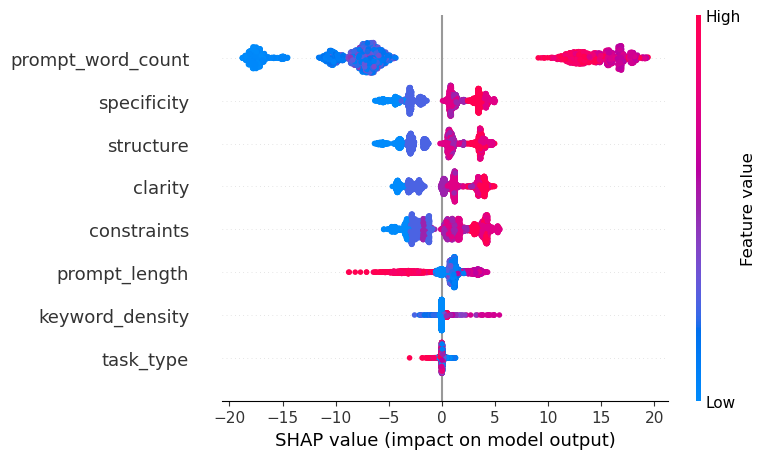

In [27]:
import shap

explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

In [28]:
# ## Making pkl file for all three models: regression model, classification model and scaler
# import joblib

# joblib.dump(xgb_reg, 'xgb_reg_model.pkl')
# joblib.dump(xgb_cls, 'xgb_cls_model.pkl')
# joblib.dump(scaler, 'min_max_scaler.pkl')